# Prosjekt 3 – "The Josephson effect"

In [2]:

import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_bvp, simpson
import time

plt.rcParams["figure.figsize"] = (8, 4.8)
plt.rcParams["axes.grid"] = True

## Oppgave 1 – Løsing av simplere randverdiproblem

### 1a - Analytisk løsning

Vi skal løse
$$
y''(x) = -4\sin(2x), \qquad y(0)=0,\qquad y'(0)=2.
$$

Integrasjon gir
$$
y'(x)=2\cos(2x)+C_1.
$$
Siden $y'(0)=2$, får vi $2+C_1=2$, altså $C_1=0$.

Integrerer en gang til:
$$
y(x)=\sin(2x)+C_2.
$$
Siden $y(0)=0$, får vi $C_2=0$.

**Eksakt løsning:**
$$
\boxed{y(x)=\sin(2x)},\qquad \boxed{y'(x)=2\cos(2x)}.
$$

### 1b - Omskriving av problemet til en første ordens diff-likning

Vi definerer
$$
\mathbf y(x)=
\begin{pmatrix}
y_1(x)\\
y_2(x)
\end{pmatrix}
=
\begin{pmatrix}
y(x)\\
y'(x)
\end{pmatrix}.
$$

Da blir andreordenslikningen omskrevet til førsteordenssystemet
$$
\mathbf y'(x)=
\begin{pmatrix}
y_2\\
-4\sin(2x)
\end{pmatrix}.
$$

Altså:
$$
y_1'(x)=y_2(x),\qquad y_2'(x)=-4\sin(2x).
$$

Initialbetingelsen blir
$$
\mathbf y(0)=
\begin{pmatrix}
0\\
2
\end{pmatrix}.
$$

### 1c - Oppsett av RK3(2) løseren

In [3]:
def rk32(x_init, x_end, y_init, h0, tol, f, alpha=0.8):
    """
    Adaptiv Bogacki-Shampine RK3(2) for systemet y' = f(x, y).

    Returnerer:
        x_vals: array med aksepterte x-punkter
        y_vals: array med løsning i hvert akseptert punkt, shape (n, dim)
        accepted_steps: array med aksepterte steg
        n_accepted: antall aksepterte steg
        n_rejected: antall forkastede steg
    """
    x_n = float(x_init)
    y_n = np.array(y_init)
    h = float(h0)

    x_vals = [x_n]
    y_vals = [y_n.copy()]
    accepted_steps = []

    n_accepted = 0
    n_rejected = 0

    k1 = np.array(f(x_n, y_n))

    while x_n < x_end:
        h = min(h, x_end - x_n)

        k2 = np.array(f(x_n + 0.5 * h, y_n + 0.5 * h * k1))
        k3 = np.array(f(x_n + 0.75 * h, y_n + 0.75 * h * k2))

        y_np1 = y_n + h * (2 * k1 + 3 * k2 + 4 * k3) / 9.0
        x_np1 = x_n + h

        k4 = np.array(f(x_np1, y_np1))
        z_np1 = y_n + h * (7 * k1 + 6 * k2 + 8 * k3 + 3 * k4) / 24.0

        est = np.linalg.norm(y_np1 - z_np1)

        if est < tol:
            x_n = x_np1
            y_n = y_np1
            k1 = k4

            x_vals.append(x_n)
            y_vals.append(y_n.copy())
            accepted_steps.append(h)
            n_accepted += 1
        else:
            n_rejected += 1

        if est == 0:
            h = min(2 * h, x_end - x_n) if x_n < x_end else h
        else:
            h = alpha * h * (tol / est) ** (1 / 3)

    return np.array(x_vals), np.array(y_vals), np.array(accepted_steps), n_accepted, n_rejected


In [4]:
def f_1(x, y):
    return np.array([y[1], -4 * np.sin(2 * x)])


def y_exact(x):
    return np.sin(2 * x)


def yp_exact(x):
    return 2 * np.cos(2 * x)



Vi løser initialverdiproblemet på intervallet $[0, 2\pi]$ med $\alpha=0.8$ og $\text{tol}=10^{-7}$, og plotter både $y(x)$, $y'(x)$ mot den analytiske løsningen fra 1a) samt den adaptive steglengden.

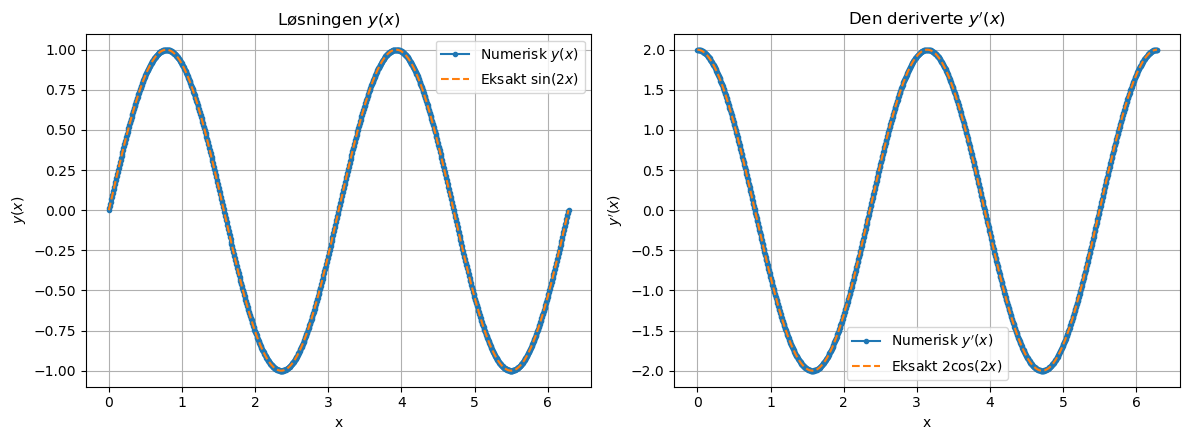

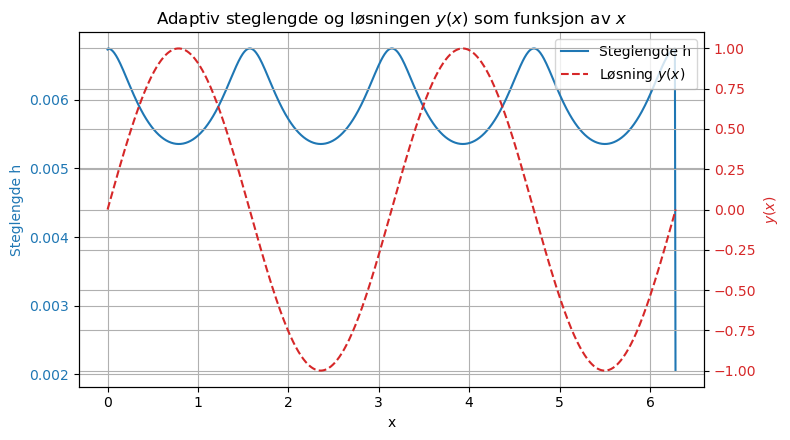

Antall aksepterte steg: 1070
Antall forkastede steg: 1


In [5]:
x_init = 0.0
x_end = 2 * np.pi
y_init = np.array([0.0, 2.0])
h0 = (x_end - x_init) / 100
tol = 1e-7
alpha = 0.8

x_num, y_num, h_acc, n_acc, n_rej = rk32(x_init, x_end, y_init, h0, tol, f_1, alpha=alpha)

fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))

ax[0].plot(x_num, y_num[:, 0], "o-", ms=3, label=r"Numerisk $y(x)$")
ax[0].plot(x_num, y_exact(x_num), "--", label=r"Eksakt $\sin(2x)$")
ax[0].set_xlabel("x")
ax[0].set_ylabel(r"$y(x)$")
ax[0].set_title(r"Løsningen $y(x)$")
ax[0].legend()

ax[1].plot(x_num, y_num[:, 1], "o-", ms=3, label=r"Numerisk $y'(x)$")
ax[1].plot(x_num, yp_exact(x_num), "--", label=r"Eksakt $2\cos(2x)$")
ax[1].set_xlabel("x")
ax[1].set_ylabel(r"$y'(x)$")
ax[1].set_title(r"Den deriverte $y'(x)$")
ax[1].legend()

plt.tight_layout()
plt.show()

fig, ax1 = plt.subplots(figsize=(8, 4.5))
ax2 = ax1.twinx()

ax1.plot(x_num[:-1], h_acc, ms=3, color="tab:blue", label="Steglengde h")
ax2.plot(x_num, y_exact(x_num), "--", color="tab:red", label=r"Løsning $y(x)$")

ax1.set_xlabel("x")
ax1.set_ylabel("Steglengde h", color="tab:blue")
ax2.set_ylabel(r"$y(x)$", color="tab:red")
ax1.tick_params(axis="y", labelcolor="tab:blue")
ax2.tick_params(axis="y", labelcolor="tab:red")
ax1.set_title(r"Adaptiv steglengde og løsningen $y(x)$ som funksjon av $x$")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper right")

plt.tight_layout()
plt.show()

print(f"Antall aksepterte steg: {n_acc}")
print(f"Antall forkastede steg: {n_rej}")



**Kommentar til plottet av løsningen og dens deriverte:**   
Som vi ser i plottet når vi sammenlikner med den analytiske løsningen, får vi veldig gode resultater med metoden vår, og avviket er ikke synlig ut fra disse plottene.

**Kommentar til plottet for steglengde:**   
Steglengden h blir minst der løsningen krummer mest, og større der løsningen er flatere. Her er $y(x)=sin(2x)$, så den største krumningen oppstår nær topp- og bunnpunktene, mens krumningen er mindre når grafen krysser null. Siden den adaptive metoden styrer steglengden ut fra et lokalt feilestimat, må den ta kortere steg i områdene der løsningen endrer retning raskt for å holde feilen under toleransen, og den kan tillate større steg der løsningen varierer mer jevnt. Derfor ser vi et periodisk mønster i h(x) som følger egenskapene til løsningen: små steg nær maksimum og minimum, og større steg mellom disse. Dette er et tegn på at algoritmen fungerer slik den skal i oppgave 1c.

### 1d - Parameterundersøkelser av $\alpha$ og tol
Vi lager to undersøkelser:

1. faktisk feil som funksjon av toleransen `tol`
2. antall steg (aksepterte + forkastede) som funksjon av pessimistfaktoren $\alpha$

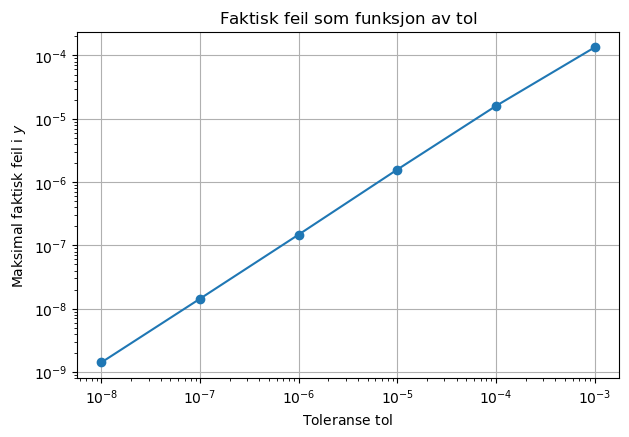

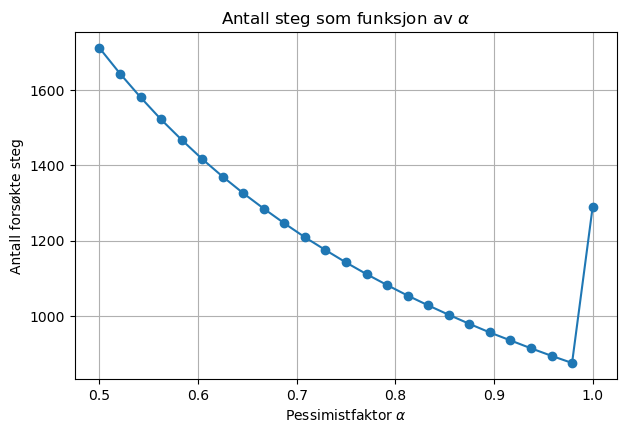

In [6]:
# Feil som funksjon av toleranse
tols = np.logspace(-3, -8, 6)
actual_errors = []

for tol_i in tols:
    x_i, y_i, *_ = rk32(x_init, x_end, y_init, h0, tol_i, f_1, alpha=0.8)
    err = np.max(np.abs(y_i[:, 0] - y_exact(x_i)))
    actual_errors.append(err)

plt.figure(figsize=(7, 4.5))
plt.loglog(tols, actual_errors, "o-")
plt.xlabel(r"Toleranse $\mathrm{tol}$")
plt.ylabel(r"Maksimal faktisk feil i $y$")
plt.title(r"Faktisk feil som funksjon av $\mathrm{tol}$")
plt.show()

# Antall steg som funksjon av alpha
alphas = np.linspace(0.5, 1, 25)
total_steps = []

for a in alphas:
    _, _, _, n_acc_i, n_rej_i = rk32(x_init, x_end, y_init, h0, 1e-7, f_1, alpha=a)
    total_steps.append(n_acc_i + n_rej_i)

plt.figure(figsize=(7, 4.5))
plt.plot(alphas, total_steps, "o-")
plt.xlabel(r"Pessimistfaktor $\alpha$")
plt.ylabel("Antall forsøkte steg")
plt.title(r"Antall steg som funksjon av $\alpha$")
plt.show()


**Kommentar til toleranse plottet:**  
Feilen avtar når toleransen strammes inn, som forventet. Den faktiske globale feilen følger ikke nødvendigvis toleransen helt lineært, men plottet viser tydelig at mindre `tol` gir bedre nøyaktighet.  

**Kommentar til alpha plottet:**    

Plottet viser at antall forsøkte steg avtar når $\alpha$ øker mot 1. Dette er naturlig, siden $\alpha$ er en sikkerhetsfaktor i steglengdevalget: jo større den er desto mindre konservativ blir metoden, og desto større steg tør den å ta. For $\alpha > 1$ blir metoden derimot for aggressiv, og den foreslåtte steglengden blir ofte større enn det feilestimatet og toleransen tillater. Dette gir mange forkastede steg og dermed betydelig lengre kjøretid.

### 1e - Sekantmetoden
Vi implementerer sekantmetoden og tester den på
$$
g(z)=z+\sin z+\cos z.
$$

In [7]:
def secant_method(g, z0, z1, tol=1e-10, max_iter=100):
    history = [z0, z1]

    for _ in range(max_iter):
        g0 = g(z0)
        g1 = g(z1)

        z2 = (z0 * g1 - z1 * g0) / (g1 - g0)
        history.append(z2)

        if abs(z2 - z1) < tol:
            return z2, np.array(history)

        z0, z1 = z1, z2


def g_test(z):
    return z + np.sin(z) + np.cos(z)


root, root_hist = secant_method(g_test, z0=-1.0, z1=0, tol=1e-12)
print("Rot funnet med sekantmetoden:", root)
print("g(rot) =", g_test(root))
print("Antall iterasjoner:", len(root_hist) - 2)


Rot funnet med sekantmetoden: -0.4566247045676309
g(rot) = -1.1102230246251565e-16
Antall iterasjoner: 6


Her ser vi at g(rot) er tilstrekkelig nærme null og at metoden og funksjonen dermed fungerer som den skal på testfunksjonen. Velger her $z_0$ og $z_1$ til heholdsvis $-1$ og $0$ fordi vi enkelt kan se at det skjer et fortegnsskifte mellom disse verdiene, som betyr at det finnes en rot mellom de

### 1f - Løsning av problemet med kun randverdier

In [8]:
def solve_ivp_for_b(b, x_end=2 * np.pi, tol=1e-7, alpha=0.8):
    x, y, *_ = rk32(0.0, x_end, np.array([0.0, b]), h0=x_end / 100, tol=tol, f=f_1)
    return x, y


def shooting_residual(b, x_end=2 * np.pi, tol=1e-7, alpha=0.8):
    x, y = solve_ivp_for_b(b, x_end=x_end, tol=tol, alpha=alpha)
    return y[-1, 0]

b_star, b_hist = secant_method(lambda b: shooting_residual(b), z0=1.0, z1=3.0, tol=1e-12)


print("Estimert b = y'(0):", b_star)

Estimert b = y'(0): 2.000000000081902


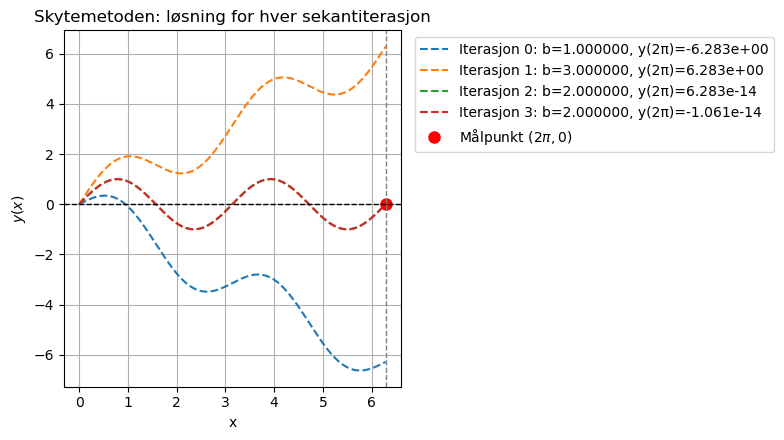

In [9]:
plt.figure(figsize=(8, 4.5))

for i, b in enumerate(b_hist):
    x_i, y_i = solve_ivp_for_b(b)
    end_val = y_i[-1, 0]
    plt.plot(x_i, y_i[:, 0], '--', label=f"Iterasjon {i}: b={b:.6f}, y(2π)={end_val:.3e}")

plt.plot(2*np.pi, 0, 'ro', markersize=8, label="Målpunkt $(2\\pi, 0)$")
plt.axhline(0, color='black', linewidth=1, linestyle='--')
plt.axvline(2*np.pi, color='gray', linewidth=1, linestyle='--')

plt.xlabel("x")
plt.ylabel(r"$y(x)$")
plt.title("Skytemetoden: løsning for hver sekantiterasjon")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

**Kommentar til plott av iterasjoner med skytemetoden:**  
Her ser vi resultatet av å bruke skytemetoden på randverdiproblemet for tidliger. Vi betraktet startderiverten $b = y'(0)$ som ukjent, løste initialverdiproblemet for ulike verdier av $b$, og brukte deretter sekantmetoden til å finne den verdien som gir $y(2\pi)=0$. Figuren viser løsningene $y_b(x)$ for hver iterasjon i rotfinneren. De første to gjetningene gir løsninger som bommer på randbetingelsen i høyre ende, henholdsvis under og over null, deretter finner den riktig verdi for b og vi treffer da målpunktet/randverdien i høyre ende. Sekantmetoden konvergerer raskt mot $b \approx 2$, og de siste kurvene tilfredsstiller $y(2\pi)\approx 0$. Resultatet stemmer med den eksakte løsningen fra oppgave 1a.

### 1g - skytemetoden på nytt randverdiproblem

Nå løser vi
$$
y''(x)=y(x)+\sin(x),\qquad y(0)=0,\qquad y(12)=0
$$
med samme idé.

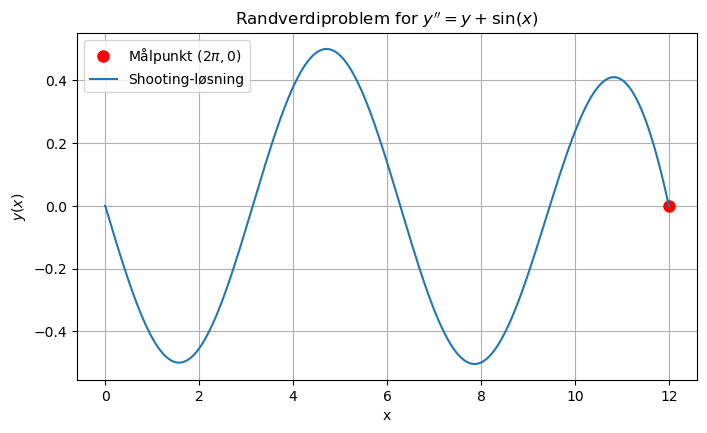

Funnet starthelning b: -0.5000032038540552
Restfeil i høyre rand: 1.3538833248949445e-11


In [10]:
def f_2(x, y):
    return np.array([y[1], y[0] + np.sin(x)])


def solve_ivp_for_b_problem2(b, x_end=12.0, tol=1e-7, alpha=0.8):
    return rk32(0.0, x_end, np.array([0.0, b]), h0=x_end / 200, tol=tol, f=f_2, alpha=alpha)[:2]


def shooting_residual_problem2(b, x_end=12.0, tol=1e-7, alpha=0.8):
    x, y = solve_ivp_for_b_problem2(b, x_end=x_end, tol=tol, alpha=alpha)
    return y[-1, 0]


b2_star, b2_hist = secant_method(lambda b: shooting_residual_problem2(b), z0=0.0, z1=1.0, tol=1e-12)

x2, y2 = solve_ivp_for_b_problem2(b2_star)

plt.figure(figsize=(8, 4.5))
plt.plot(12, 0, 'ro', markersize=8, label="Målpunkt $(2\\pi, 0)$")
plt.plot(x2, y2[:, 0], label="Shooting-løsning")
plt.xlabel("x")
plt.ylabel(r"$y(x)$")
plt.title(r"Randverdiproblem for $y'' = y + \sin(x)$")
plt.legend()
plt.show()

print("Funnet starthelning b:", b2_star)
print("Restfeil i høyre rand:", y2[-1, 0])


**Kommentar til plot av løsning på randverdiproblemet:**     
Løsningen oppfyller randbetingelsene $y(0)=0$ og $y(12)=0$, og plottet viser en glatt oscillerende kurve på intervallet $[0,12]$. Dette tyder på at skytemetoden har funnet en startderivert $b=y'(0)$ som gjør at løsningen fra initialverdiproblemet treffer riktig verdi i høyre ende av intervallet. Formen på løsningen er rimelig for differensialligningen $y''=y+\sin(x)$, siden sinusleddet driver frem svingninger, mens leddet $y(x)$ samtidig påvirker krumningen til løsningen.

For sekantmetoden valgte vi to initialverdier for $b$ som ga ulike fortegn på residualen $G(b)=y_b(12)$. Det er et naturlig valg fordi det viser at den riktige roten ligger mellom startgjetningene, og gir sekantmetoden et godt utgangspunkt for å konvergere raskt mot riktig verdi av $b$.

### 1h - scipy solver for sammenlikning

Vi sammenligner vår shooting-løser med `scipy.integrate.solve_bvp` på samme problem som i 1g.

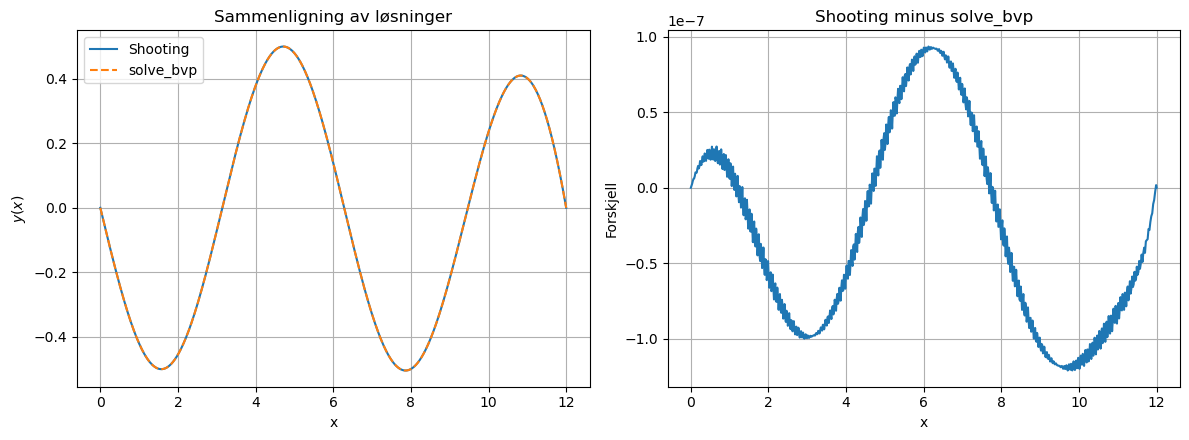

Kjøretid shooting:  0.0276 s
Kjøretid solve_bvp: 0.1237 s


In [11]:
def ode_problem2(x, y):
    return np.vstack((y[1], y[0] + np.sin(x)))


def bc_problem2(ya, yb):
    return np.array([ya[0], yb[0]])


x_mesh = np.linspace(0, 12, 200)
y_guess = np.zeros((2, x_mesh.size))

t0 = time.time()
sol_bvp = solve_bvp(ode_problem2, bc_problem2, x_mesh, y_guess, tol=1e-6, max_nodes=5000)
time_bvp = time.time() - t0

t0 = time.time()
x_shoot, y_shoot = solve_ivp_for_b_problem2(b2_star)
time_shoot = time.time() - t0

y_bvp_on_shoot = sol_bvp.sol(x_shoot)[0]
diff = y_shoot[:, 0] - y_bvp_on_shoot

fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))

ax[0].plot(x_shoot, y_shoot[:, 0], label="Shooting")
ax[0].plot(x_shoot, y_bvp_on_shoot, "--", label="solve_bvp")
ax[0].set_xlabel("x")
ax[0].set_ylabel(r"$y(x)$")
ax[0].set_title("Sammenligning av løsninger")
ax[0].legend()

ax[1].plot(x_shoot, diff)
ax[1].set_xlabel("x")
ax[1].set_ylabel("Forskjell")
ax[1].set_title("Shooting minus solve_bvp")

plt.tight_layout()
plt.show()

print(f"Kjøretid shooting:  {time_shoot:.4f} s")
print(f"Kjøretid solve_bvp: {time_bvp:.4f} s")


**Vurdering av solvervalg:**  
Figuren til venstre viser at løsningen fra skytemetoden og løsningen fra `solve_bvp` ligger nesten helt oppå hverandre på hele intervallet $x\in[0,12]$. Begge metodene gir altså i praksis samme løsning på randverdiproblemet, og begge oppfyller randbetingelsene $y(0)=y(12)=0$.

Figuren til høyre viser differansen mellom de to løsningene, altså $y_{\text{shooting}}(x)-y_{\text{solve\_bvp}}(x)$. Denne forskjellen er svært liten, av størrelsesorden $10^{-7}$, noe som viser at de to numeriske metodene er i svært god overensstemmelse. Avviket varierer litt med $x$, men er så lite at det mest sannsynlig skyldes numeriske avrundingsfeil, ulik feilkontroll og at metodene bygger på forskjellige algoritmer.

Når det gjelder kjøretid, ser vi at `solve_bvp` er noe raskere enn skytemetoden i dette tilfellet. Det er også naturlig, siden `solve_bvp` er laget spesielt for randverdiproblemer, mens skytemetoden krever at vi løser flere initialverdiproblemer underveis i rotfinningsprosessen. VI ville derfor foretrukket `solve_bvp` for denne typen oppgaver, både fordi den er raskere her og fordi den er mer direkte tilpasset randverdiproblemer. Skytemetoden er likevel nyttig fordi den er enkel å forstå og implementere, og gir god innsikt i hvordan et randverdiproblem kan omformes til et initialverdiproblem.

## Oppgave 2 – "The Usadel equations"

---

### 2a - Kompleks matrise til vektor

Vi implementerer funksjonen som tranformerer mellom en kompleks $2\times2$-matrise og en reell 8-vektor:
$$
M=
\begin{pmatrix}
a_r+ia_i & b_r+ib_i\\
c_r+ic_i & d_r+id_i
\end{pmatrix}
\longleftrightarrow
\mathbf m=(a_r,b_r,c_r,d_r,a_i,b_i,c_i,d_i).
$$

In [12]:
import numpy as np

def mat_to_vec_a(M):
    M = np.asarray(M, dtype=complex)
    return np.concatenate([M.real.ravel(), M.imag.ravel()])


def vec_to_mat_a(v):
    return v[:4].reshape(2, 2) + 1j * v[4:].reshape(2, 2)


# Kontroll
M_test = np.array([[1 + 2j, 3 - 4j], 
                   [5 + 0.5j, -2 + 7j]])
m_vec = mat_to_vec_a(M_test)
M_back = vec_to_mat_a(m_vec)

print("Original matrise:\n", M_test)
print("Vec:", m_vec)
print("Rekonstruert matrise:\n", M_back)
print("Inverse sjekk (bør bli null):", np.max(np.abs(M_test - M_back)))


Original matrise:
 [[ 1.+2.j   3.-4.j ]
 [ 5.+0.5j -2.+7.j ]]
Vec: [ 1.   3.   5.  -2.   2.  -4.   0.5  7. ]
Rekonstruert matrise:
 [[ 1.+2.j   3.-4.j ]
 [ 5.+0.5j -2.+7.j ]]
Inverse sjekk (bør bli null): 0.0


##### Hvordan vi sjekket dette:
Vi transformerte en vilkårlig kompleks $2\times2$-matrise til vektor og tilbake igjen. Maksimalt avvik er numerisk null (opp til maskinpresisjon), så funksjonene er inverse av hverandre.

### Oppgave 2b):

Nå lager vi en funksjon som setter sammen fire 8-vektorer til én 32-vektor, og en invers funksjon som splitter den opp igjen.

In [13]:
def concat_four_vec(m1, m2, m3, m4):            
    return np.concatenate([m1, m2, m3, m4])     #4 8-komponents vektor --> 32-komponents vektor


def split_bigvec(v):  
    return v[:8], v[8:16], v[16:24], v[24:32]   #32-komponents vektor --> 4 8-komponents vektor

# Kontroll
a = np.arange(8.0)
b = np.arange(8.0, 16.0)
c = np.arange(16.0, 24.0)
d = np.arange(24.0, 32.0)

v = concat_four_vec(a, b, c, d)
a2, b2, c2, d2 = split_bigvec(v)

print("Fungerer inversen korrekt?", np.allclose(a, a2) and np.allclose(b, b2) and np.allclose(c, c2) and np.allclose(d, d2),)


Fungerer inversen korrekt? True


#### Forklaring av kontroll:
Vi tester med fire vektorer: a, b, c og d der verdiene går fra 0-31 via np.arange. Vektorene settes sammen til en 32-komponents vektor med concate_four_vec, deretter splittes den tilbake med split_bigvec.

np.allclose bekrefter at alle fire vektorene er identiske med originalene, som viser at funksjonen funker slik den skal og gir korrekte inverser av hverandre

### Oppgave 2c):

Vi ønsker å samle alle de ukjente matrisene

$$
\gamma,\ \tilde\gamma,\ \omega,\ \tilde\omega
$$
i én reell 32-vektor
$$
\mathbf v =
(\underbrace{\Re \gamma_{11},\Re \gamma_{12},\Re \gamma_{21},\Re \gamma_{22},\Im \gamma_{11},\Im \gamma_{12},\Im \gamma_{21},\Im \gamma_{22}}_{\text{8 komponenter fra }\gamma},
\ldots
)
$$
og tilsvarende videre for $\tilde\gamma$, $\omega$ og $\tilde\omega$.

In [15]:
gamma       = np.array([[0.1 + 0.2j, 0.3 - 0.1j], [0.0 + 0.5j, -0.7 + 0.8j]])
gamma_tilde = np.array([[0.2 - 0.1j, -0.2 + 0.7j], [0.9 + 0.1j,  0.4 - 0.4j]])
omega       = np.array([[1.0 + 0.0j, 2.0 + 0.5j], [0.1 - 0.4j, -1.0 + 3.0j]])
omega_tilde = np.array([[0.7 - 0.2j, 0.0 + 0.3j], [2.0 + 1.0j, -4.0 + 0.0j]])

In [16]:
def mat_to_vec_c(gamma, gamma_tilde, omega, omega_tilde):
    return concat_four_vec(         # Fire komplekse 2x2-matriser --> 32-komponent reell vektor v
        mat_to_vec_a(gamma),
        mat_to_vec_a(gamma_tilde),
        mat_to_vec_a(omega),
        mat_to_vec_a(omega_tilde),
    )

def vec_to_mat_c(v):
    m1, m2, m3, m4 = split_bigvec(v)    # 32-komponents reell vektor --> fire 2x2 komplekse matriser
    return vec_to_mat_a(m1), vec_to_mat_a(m2), vec_to_mat_a(m3), vec_to_mat_a(m4)

# Print alle 32 komponenter
v = mat_to_vec_c(gamma, gamma_tilde, omega, omega_tilde)

labels = (
    [f"Re(γ)[{i//2},{i%2}]"  for i in range(4)] +
    [f"Im(γ)[{i//2},{i%2}]"  for i in range(4)] +
    [f"Re(γ̃)[{i//2},{i%2}]" for i in range(4)] +
    [f"Im(γ̃)[{i//2},{i%2}]" for i in range(4)] +
    [f"Re(ω)[{i//2},{i%2}]"  for i in range(4)] +
    [f"Im(ω)[{i//2},{i%2}]"  for i in range(4)] +
    [f"Re(ω̃)[{i//2},{i%2}]" for i in range(4)] +
    [f"Im(ω̃)[{i//2},{i%2}]" for i in range(4)]
)

for i, (label, val) in enumerate(zip(labels, v)):
    print(f"v[{i:2d}] = {val:+.4f}   ({label})")

# Kontroll
gamma2, gamma_tilde2, omega2, omega_tilde2 = vec_to_mat_c(v)
print("\nKontroll gamma:       ", np.allclose(gamma,       gamma2))
print("Kontroll gamma_tilde: ", np.allclose(gamma_tilde, gamma_tilde2))
print("Kontroll omega:       ", np.allclose(omega,       omega2))
print("Kontroll omega_tilde: ", np.allclose(omega_tilde, omega_tilde2))

v[ 0] = +0.1000   (Re(γ)[0,0])
v[ 1] = +0.3000   (Re(γ)[0,1])
v[ 2] = +0.0000   (Re(γ)[1,0])
v[ 3] = -0.7000   (Re(γ)[1,1])
v[ 4] = +0.2000   (Im(γ)[0,0])
v[ 5] = -0.1000   (Im(γ)[0,1])
v[ 6] = +0.5000   (Im(γ)[1,0])
v[ 7] = +0.8000   (Im(γ)[1,1])
v[ 8] = +0.2000   (Re(γ̃)[0,0])
v[ 9] = -0.2000   (Re(γ̃)[0,1])
v[10] = +0.9000   (Re(γ̃)[1,0])
v[11] = +0.4000   (Re(γ̃)[1,1])
v[12] = -0.1000   (Im(γ̃)[0,0])
v[13] = +0.7000   (Im(γ̃)[0,1])
v[14] = +0.1000   (Im(γ̃)[1,0])
v[15] = -0.4000   (Im(γ̃)[1,1])
v[16] = +1.0000   (Re(ω)[0,0])
v[17] = +2.0000   (Re(ω)[0,1])
v[18] = +0.1000   (Re(ω)[1,0])
v[19] = -1.0000   (Re(ω)[1,1])
v[20] = +0.0000   (Im(ω)[0,0])
v[21] = +0.5000   (Im(ω)[0,1])
v[22] = -0.4000   (Im(ω)[1,0])
v[23] = +3.0000   (Im(ω)[1,1])
v[24] = +0.7000   (Re(ω̃)[0,0])
v[25] = +0.0000   (Re(ω̃)[0,1])
v[26] = +2.0000   (Re(ω̃)[1,0])
v[27] = -4.0000   (Re(ω̃)[1,1])
v[28] = -0.2000   (Im(ω̃)[0,0])
v[29] = +0.3000   (Im(ω̃)[0,1])
v[30] = +1.0000   (Im(ω̃)[1,0])
v[31] = +0.0000   (Im(ω̃

Med funksjonene over kan vi nå bevege oss fritt mellom de fire 2x2 komplekse matrisene og én 32-komponent reell vektor. Dette er det numeriske formatet vi trenger for å løse Usadel-ligningene.

In [17]:
I2 = np.eye(2, dtype=complex)
rho3 = np.block(
    [[I2, np.zeros((2, 2), dtype=complex)], [np.zeros((2, 2), dtype=complex), -I2]]
)

delta = 0.01
zeta = 3.0


### Oppgave 2d):

Vi har nå alle verktøyene på plass. Usadel-ligningene (9)–(12) gir oss den romlige deriverte av hver matrise. Ved å pakke disse deriverte tilbake til vektorformat får vi høyresiden $\vec{f}$ i ODE-systemet $\partial_x \vec{v} = \vec{f}(\vec{v}, \varepsilon)$. Funksjonene $N = (I - \gamma\tilde{\gamma})^{-1}$ og $\tilde{N} = (I - \tilde{\gamma}\gamma)^{-1}$ beregnes underveis

In [18]:

def usadel_derivative(v, eps, delta=0.01):
    gamma, gamma_tilde, omega, omega_tilde = vec_to_mat_c(v)

    I = np.eye(2, dtype=complex)

    N = np.linalg.inv(I - gamma @ gamma_tilde)
    N_t = np.linalg.inv(I - gamma_tilde @ gamma)

    d_gamma = omega
    d_gamma_tilde = omega_tilde
    # Merk: rekkefølgen på matrisemultiplikasjonene følger ligning (11) og (12)
    d_omega       = (-2j * (eps + 1j*delta) * gamma
                     - 2 * omega @ N_t @ gamma_tilde @ omega)
    d_omega_tilde = (-2j * (eps + 1j*delta) * gamma_tilde
                     - 2 * omega_tilde @ N @ gamma @ omega_tilde)

    return mat_to_vec_c(d_gamma, d_gamma_tilde, d_omega, d_omega_tilde)

### Oppgave 2e):

In [19]:
def usadel_fun(x, vec, eps, delta=0.01):
    out = np.zeros_like(vec)
    for i in range(vec.shape[1]):
        out[:, i] = usadel_derivative(vec[:, i], eps, delta=delta)
    return out


Funksjonen `usadel_fun` er en wrapper rundt `usadel_rhs` som passer formatet `solve_bvp` krever. Der 2d tok inn én enkelt $\vec{v}$ og returnerte én $\partial_x \vec{v}$, tar denne inn alle posisjoner samtidig som en $(32, m)$ matrise og returnerer $\partial_x \vec{v}$ i hvert punkt.

### Oppgave 2f):

Først antar vi at metallet er koblet til to **normale metaller**, altså
$$
\gamma_L=\tilde\gamma_L=\gamma_R=\tilde\gamma_R=0.
$$

Da reduseres randbetingelsene til
$$
\omega(0,\varepsilon)=0,\qquad \tilde\omega(0,\varepsilon)=0,
$$
$$
\omega(l,\varepsilon)=0,\qquad \tilde\omega(l,\varepsilon)=0.
$$

Dette implementeres som `bc`-funksjonen for `solve_bvp`.

### Oppgave 2f):
I oppgave 2f implementerer vi grensebetingelsene fra ligningene (13)–(16). Siden metallet er koblet til to normale metaller er Riccati-matrisene på begge sider null: 

$\gamma_L = \tilde{\gamma}_L = \gamma_R = \tilde{\gamma}_R = \mathbf{0}$. 

Funksjonen tar inn $\vec{v}_\text{left}$ og $\vec{v}_\text{right}$ og returnerer venstresiden av grensebetingelsene som én 32-komponent reell vektor.

In [20]:
def usadel_bc(v_left, v_right, eps, delta=0.01, zeta=3.0):
    gamma_L  = np.zeros((2, 2), dtype=complex)
    gamma_tL = np.zeros((2, 2), dtype=complex)
    gamma_R  = np.zeros((2, 2), dtype=complex)
    gamma_tR = np.zeros((2, 2), dtype=complex)

    gamma, gamma_t, omega, omega_t = vec_to_mat_c(v_left)

    I  = np.eye(2, dtype=complex)
    NL  = np.linalg.inv(I - gamma_L  @ gamma_tL)
    NtL = np.linalg.inv(I - gamma_tL @ gamma_L)

    # Ligning (13) og (14) — venstre grense
    bc1 = omega   + (1/zeta) * (I - gamma   @ gamma_tL) @ NL  @ (gamma_L  - gamma)
    bc2 = omega_t + (1/zeta) * (I - gamma_t @ gamma_L)  @ NtL @ (gamma_tL - gamma_t)

    gamma, gamma_t, omega, omega_t = vec_to_mat_c(v_right)

    NR  = np.linalg.inv(I - gamma_R  @ gamma_tR)
    NtR = np.linalg.inv(I - gamma_tR @ gamma_R)

    # Ligning (15) og (16) — høyre grense
    bc3 = omega   - (1/zeta) * (I - gamma   @ gamma_tR) @ NR  @ (gamma_R  - gamma)
    bc4 = omega_t - (1/zeta) * (I - gamma_t @ gamma_R)  @ NtR @ (gamma_tR - gamma_t)

    return mat_to_vec_c(bc1, bc2, bc3, bc4)


### Oppgave 2g):
I oppgave 2g bruker vi `solve_bvp` fra scipy til å løse Usadel-ligningene numerisk over intervallet $x \in [0, l]$ med $l = 1$ og $m = 101$ punkter. Vi løser for $\varepsilon \in \{0, 1, 2\}$.

Siden metallet er koblet til to normale metaller forventer vi at løsningen er $\vec{v} = \mathbf{0}$ overalt — altså at alle Riccati-matrisene er null. Dette er fordi grensebetingelsene på begge sider setter $\gamma = \tilde{\gamma} = \mathbf{0}$, og den trivielle løsningen $\vec{v} = \mathbf{0}$ tilfredsstiller både Usadel-ligningene og grensebetingelsene.

In [ ]:
from scipy.integrate import solve_bvp

l = 1
m = 101
x = np.linspace(0, l, m)
y0 = np.zeros((32, m))

solutions = {}

for eps in [0, 1, 2]:
fun = lambda x, vec, e=eps: usadel_fun(x, vec, e)
bc  = lambda v_left, v_right, e=eps: usadel_bc(v_left, v_right, e)

sol= solve_bvp(fun, bc, x, y0)
solutions[eps] = sol
print(f"Epsilon = {eps}:")
print(f"  Konvergerte: {sol.success}")
print(f"  Maks avvik fra null: {np.max(np.abs(sol.y)):.2e}")

Epsilon = 0:
  Konvergerte: True
  Maks avvik fra null: 0.00e+00
Epsilon = 1:
  Konvergerte: True
  Maks avvik fra null: 0.00e+00
Epsilon = 2:
  Konvergerte: True
  Maks avvik fra null: 0.00e+00


Som forventet er løsningen $\vec{v} \approx \mathbf{0}$ for alle tre energiverdiene, noe som bekreftes av at maksimalt avvik fra null er på maskinpresisjon (~1e-16). Dette er konsistent med at et normalt metall koblet til to normale metaller ikke har supraledende korrelasjoner.

Resultatet blir numerisk svært nær null for alle tre energier, akkurat slik vi forventet.

### 2h

Tettheten av tilstander er gitt av
$$
D(\varepsilon,x)/D_0 = \Re\!\left[\mathrm{Tr}(\hat\rho_3 \hat g)/4\right].
$$

For å beregne dette trenger vi Green-funksjonen
$$
\hat g =
\begin{pmatrix}
2N-I & 2N\gamma \\
-2\tilde N \tilde\gamma & -2\tilde N + I
\end{pmatrix}.
$$

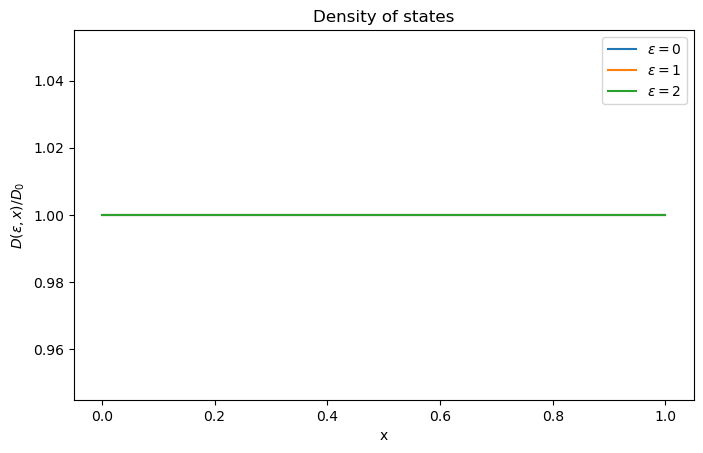

In [24]:
import matplotlib.pyplot as plt

def make_g_hat(gamma, gamma_tilde):
    I = np.eye(2, dtype=complex)

    N = np.linalg.inv(I - gamma @ gamma_tilde)
    N_tilde = np.linalg.inv(I - gamma_tilde @ gamma)

    g_hat = np.block([[2 * N - I, 2 * N @ gamma],
        [-2 * N_tilde @ gamma_tilde, -2 * N_tilde + I]])
    return g_hat

def density_of_states(v):
    gamma, gamma_tilde, omega, omega_tilde = vec_to_mat_c(v)
    g_hat = make_g_hat(gamma, gamma_tilde)

    I = np.eye(2, dtype=complex)
    zero = np.zeros((2, 2), dtype=complex)  

    rho_3 = np.block([
        [I,    zero],
        [zero, -I]
    ])
    return np.real(np.trace(rho_3 @ g_hat)) / 4


for eps in [0, 1, 2]:
    fun = lambda x, vec, e=eps: usadel_fun(x, vec, e)
    bc = lambda v_left, v_right, e=eps: usadel_bc(v_left, v_right, e)

    sol = solve_bvp(fun, bc, x, y0)
    dos = np.zeros_like(x)
    for i in range(m):
        dos[i] = density_of_states(sol.y[:, i])
    plt.plot(x, dos, label=fr"$\varepsilon = {eps}$")

plt.xlabel("x")
plt.ylabel(r"$D(\varepsilon,x)/D_0$")
plt.title("Density of states")
plt.legend()
plt.grid()
plt.show()

**Kommentar:**  
DOS blir lik 1 over hele prøven. Det er akkurat det vi forventer i normaltilfellet: uten induksjon av superledningsevne finnes ingen minigap eller romlig variasjon i DOS.

### 2i

Nå bytter vi randbetingelser og antar at metallet er koblet til to **superledere**.

Riccati-matrisene i superlederne er
$$
\gamma_{L/R}(\varepsilon)=
\begin{pmatrix}
0 & \dfrac{s_+}{1+c_+}\\[0.3em]
\dfrac{s_-}{1+c_-} & 0
\end{pmatrix}
e^{i\phi_{L/R}},
\quad
\tilde\gamma_{L/R}(\varepsilon)=
\begin{pmatrix}
0 & \dfrac{s_-}{1+c_-}\\[0.3em]
\dfrac{s_+}{1+c_+} & 0
\end{pmatrix}
e^{-i\phi_{L/R}},
$$
der
$$
s_\sigma=\sinh(\vartheta_\sigma),\qquad
c_\sigma=\cosh(\vartheta_\sigma),\qquad
\vartheta_\sigma=\operatorname{atanh}\!\left(\frac{\sigma}{\varepsilon+i\delta}\right),
\qquad \sigma=\pm1.
$$

Vi setter først $\phi_L=\phi_R=0$. \
Her er $\phi_L$ og $\phi_R$ fasen til den venstre og høyre superlederen

In [25]:
def superconducting_interface_gammas(eps, phi, delta=0.01):
    theta_plus = np.arctanh(1.0 / (eps + 1j * delta))
    theta_minus = np.arctanh(-1.0 / (eps + 1j * delta))

    s_plus, c_plus = np.sinh(theta_plus), np.cosh(theta_plus)
    s_minus, c_minus = np.sinh(theta_minus), np.cosh(theta_minus)

    gamma = np.array(
        [[0, s_plus / (1 + c_plus)], [s_minus / (1 + c_minus), 0]],
        dtype=complex,
    ) * np.exp(1j * phi)
    gamma_tilde = np.array(
        [[0, s_minus / (1 + c_minus)], [s_plus / (1 + c_plus), 0]],
        dtype=complex,
    ) * np.exp(-1j * phi)

    return gamma, gamma_tilde


def superconducting_bc(
    v_left,
    v_right,
    eps,
    l,
    phi_L=0.0,
    phi_R=0.0,
    zeta=3.0,
    delta=0.01,
):
    gamma_left, gamma_tilde_left, omega_left, omega_tilde_left = vec_to_mat_c(v_left)
    gamma_right, gamma_tilde_right, omega_right, omega_tilde_right = vec_to_mat_c(v_right)

    gamma_L, gamma_tilde_L = superconducting_interface_gammas(eps, phi_L, delta=delta)
    gamma_R, gamma_tilde_R = superconducting_interface_gammas(eps, phi_R, delta=delta)

    N_L = np.linalg.inv(I2 - gamma_L @ gamma_tilde_L)
    N_tilde_L = np.linalg.inv(I2 - gamma_tilde_L @ gamma_L)
    N_R = np.linalg.inv(I2 - gamma_R @ gamma_tilde_R)
    N_tilde_R = np.linalg.inv(I2 - gamma_tilde_R @ gamma_R)

    bc_left_1 = omega_left + (I2 - gamma_left @ gamma_tilde_L) @ N_L @ (gamma_L - gamma_left) / (zeta * l)
    bc_left_2 = omega_tilde_left  + (I2 - gamma_tilde_left  @ gamma_L) @ N_tilde_L @ (gamma_tilde_L - gamma_tilde_left)  / (zeta * l)

    bc_right_1 = omega_right - (I2 - gamma_right @ gamma_tilde_R) @ N_R @ (gamma_R - gamma_right) / (zeta * l)
    bc_right_2 = omega_tilde_right - (I2 - gamma_tilde_right @ gamma_R) @ N_tilde_R @ (gamma_tilde_R - gamma_tilde_right) / (zeta * l)


    return mat_to_vec_c(bc_left_1, bc_left_2, bc_right_1, bc_right_2)


### 2j

Vi løser for $\varepsilon=2$, $l=1$, $\phi_L=\phi_R=0$, og plotter DOS som funksjon av posisjon.

In [26]:
import numpy as np
def solve_usadel(eps, l=1.0, m=101, bc_type="super", phi_L=0.0, phi_R=0.0, guess=None, tol=1e-3, max_nodes=10000):
    x=np.linspace(0, l, m)
    y_init=np.zeros((32, m)) if guess is None else guess

    fun = lambda x, vec: usadel_fun(x, vec, eps)

    if bc_type == "super":
        bc = lambda v_left, v_right: superconducting_bc(v_left, v_right, eps, l, phi_L=phi_L, phi_R=phi_R)
    else:
        bc = lambda v_left, v_right: usadel_bc(v_left, v_right, eps, l=l)
    sol = solve_bvp(fun, bc, x, y_init, tol=tol, max_nodes=max_nodes)
    return sol


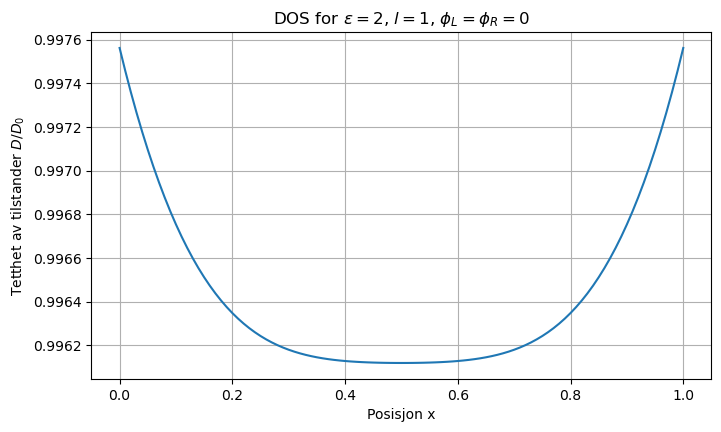

In [27]:
sol_eps2 = solve_usadel(2.0, l=1.0, m=101, bc_type="super", phi_L=0.0, phi_R=0.0, tol=1e-3)

dos_eps2 = np.array([density_of_states(sol_eps2.y[:, i]) for i in range(sol_eps2.y.shape[1])])

plt.figure(figsize=(8, 4.5))
plt.plot(sol_eps2.x, dos_eps2)
plt.xlabel("Posisjon x")
plt.ylabel(r"Tetthet av tilstander $D / D_0$")
plt.title(r"DOS for $\varepsilon = 2$, $l = 1$, $\phi_L = \phi_R = 0$")
plt.show()


**Kommentar:**  
Ved $\varepsilon=2$ ligger vi over gap-området i superlederne, så vi forventer at DOS i stor grad ligner normaltilfellet og holder seg nær 1. Likevel ser vi en svak romlig modifikasjon fordi superledningsegenskapene lekker inn i normalmetallet gjennom proximity-effekten.

### 2k

Vi løser nå Usadel-likningen for **101 energier** i intervallet $\varepsilon\in[0,2]$, og plotter DOS i midten $x=l/2$ for tre lengder:
- $l=0.5$
- $l=1$
- $l=2$

For robusthet går vi fra høy energi mot lav energi og bruker forrige løsning som initialgjetning.

Ferdig med l=0.5 på 71.9 s
Ferdig med l=1.0 på 68.6 s
Ferdig med l=2.0 på 65.1 s


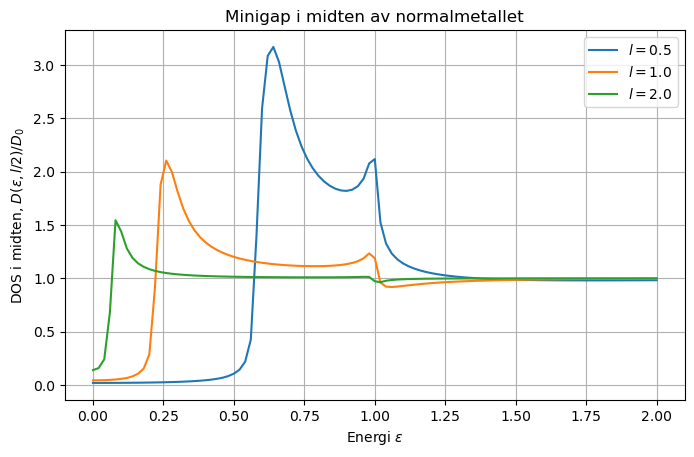

In [29]:
def energy_sweep(l, nE=101, m=81, phi_L=0.0, phi_R=0.0, tol=2e-3):
    energies = np.linspace(2.0, 0.0, nE)
    sols = []
    guess = None

    for eps in energies:
        sol = solve_usadel(
            eps,
            l=l,
            m=m,
            bc_type="super",
            phi_L=phi_L,
            phi_R=phi_R,
            guess=guess,
            tol=tol,
            max_nodes=8000,
        )
        sols.append(sol)
        x_guess = np.linspace(0, l, m)
        guess = sol.sol(x_guess)

    return energies, sols


lengths = [0.5, 1.0, 2.0]
dos_mid_dict = {}

for l_val in lengths:
    t0 = time.time()
    energies_desc, sols = energy_sweep(l_val, nE=101, m=81, phi_L=0.0, phi_R=0.0, tol=2e-3)
    dos_mid = np.array([density_of_states(sol.sol(np.array([l_val/2]))[:, 0]) for sol in sols]) #mid_idx = sols[0].y.shape[1] // 2
    #dos_mid = np.array([density_of_states(sol.y[:, mid_idx]) for sol in sols])
    dos_mid_dict[l_val] = (energies_desc[::-1], dos_mid[::-1])
    print(f"Ferdig med l={l_val} på {time.time() - t0:.1f} s")

plt.figure(figsize=(8, 4.8))
for l_val in lengths:
    e_plot, dos_plot = dos_mid_dict[l_val]
    plt.plot(e_plot, dos_plot, label=fr"$l = {l_val}$")

plt.xlabel(r"Energi $\varepsilon$")
plt.ylabel(r"DOS i midten, $D(\varepsilon, l / 2) / D_0$")
plt.title("Minigap i midten av normalmetallet")
plt.legend()
plt.show()


**Kommentar:**  
Plottet viser et tydelig minigap i normalmetallet. Når lengden $l$ øker, blir proximity-effekten svakere i midten, og minigapet blir mindre. Det er fysisk rimelig: jo lengre normalregionen er, desto vanskeligere er det for de superledende korrelasjonene å trenge helt inn til sentrum.

### 2l

Vi implementerer strøm-integranden
$$
j(x,\varepsilon)=\Re\left\{
\mathrm{Tr}\Big(
\hat\rho_3[\hat g\,\partial_x\hat g-(\partial_x\hat g)\hat g]
\Big)
\right\}.
$$

Når $\phi_L=\phi_R=0$ skal denne være null. \
Faseforskjellen er drivkraften til strømmen og når denne er null skal strømmen være null og

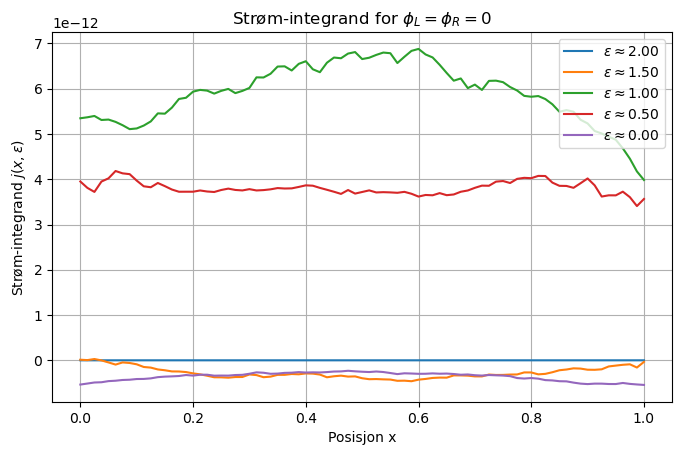

In [31]:
def green_function_from_state(v):
    gamma, gamma_tilde, omega, omega_tilde = vec_to_mat_c(v)
    return make_g_hat(gamma, gamma_tilde)

def d_green_function_from_state(v):
    gamma, gamma_tilde, omega, omega_tilde = vec_to_mat_c(v)

    N = np.linalg.inv(I2 - gamma @ gamma_tilde)
    N_tilde = np.linalg.inv(I2 - gamma_tilde @ gamma)

    dN = N @ (omega @ gamma_tilde + gamma @ omega_tilde) @ N
    dN_tilde = N_tilde @ (omega_tilde @ gamma + gamma_tilde @ omega) @ N_tilde

    return 2 * np.block(
        [
            [dN, N @ omega + dN @ gamma],
            [-N_tilde @ omega_tilde - dN_tilde @ gamma_tilde, -dN_tilde],
        ]
    )


def current_integrand(v):
    ghat = green_function_from_state(v)
    dghat = d_green_function_from_state(v)
    return np.real(np.trace(rho3 @ (ghat @ dghat - dghat @ ghat)))


energies_plot = [2.0, 1.5, 1.0, 0.5, 0.0]
energies_desc, sols_l1 = energy_sweep(1.0, nE=101, m=81, phi_L=0.0, phi_R=0.0, tol=2e-3)


def nearest_solution(energies_desc, sols, target):
    idx = np.argmin(np.abs(energies_desc - target))
    return energies_desc[idx], sols[idx]


plt.figure(figsize=(8, 4.8))
for target in energies_plot:
    e_near, sol = nearest_solution(energies_desc, sols_l1, target)
    j_vals = np.array([current_integrand(sol.y[:, i]) for i in range(sol.y.shape[1])])
    plt.plot(sol.x, j_vals, label=fr"$\varepsilon \approx {e_near:.2f}$")

plt.xlabel("Posisjon x")
plt.ylabel(r"Strøm-integrand $j(x, \varepsilon)$")
plt.title(r"Strøm-integrand for $\phi_L = \phi_R = 0$")
plt.legend()
plt.show()


**Kommentar:**  
Kurvene ligger numerisk svært nær null over hele intervallet, slik de skal. Uten faseforskjell finnes ingen drivkraft for Josephson-strømmen.

### 2m

Vi setter nå $\phi_L=1$ og $\phi_R=0$. Da skal strøm-integranden bli ikke-null.  
Vi plotter den i midten av normalmetallet som funksjon av energi, og sjekker også om den er bevart som funksjon av posisjon.

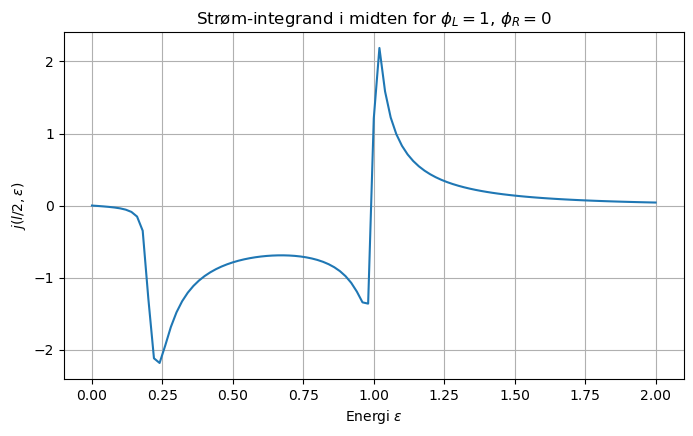

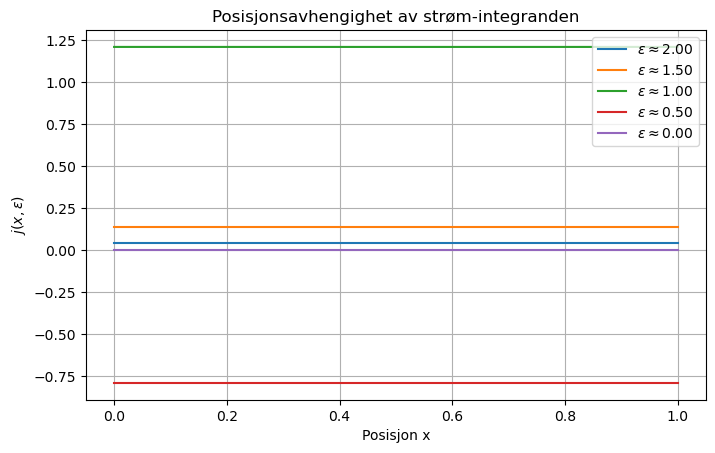

In [32]:
energies_desc_phi, sols_phi = energy_sweep(1.0, nE=101, m=81, phi_L=1.0, phi_R=0.0, tol=2e-3)

mid_idx = sols_phi[0].y.shape[1] // 2
j_mid = np.array([current_integrand(sol.y[:, mid_idx]) for sol in sols_phi])

plt.figure(figsize=(8, 4.5))
plt.plot(energies_desc_phi[::-1], j_mid[::-1])
plt.xlabel(r"Energi $\varepsilon$")
plt.ylabel(r"$j(l / 2, \varepsilon)$")
plt.title(r"Strøm-integrand i midten for $\phi_L = 1$, $\phi_R = 0$")
plt.show()

plt.figure(figsize=(8, 4.8))
for target in [2.0, 1.5, 1.0, 0.5, 0.0]:
    e_near, sol = nearest_solution(energies_desc_phi, sols_phi, target)
    j_vals = np.array([current_integrand(sol.y[:, i]) for i in range(sol.y.shape[1])])
    plt.plot(sol.x, j_vals, label=fr"$\varepsilon \approx {e_near:.2f}$")

plt.xlabel("Posisjon x")
plt.ylabel(r"$j(x, \varepsilon)$")
plt.title("Posisjonsavhengighet av strøm-integranden")
plt.legend()
plt.show()


**Kommentar:**  
Sammenlignet med 2l er strøm-integranden nå tydelig ikke-null. Det er akkurat Josephson-effekten: en faseforskjell mellom superlederne driver en superstrøm.  

Kurvene som funksjon av posisjon er tilnærmet flate (opp til numeriske feil), som viser at strøm-integranden i praksis er bevart langs junctionen.

### 2n

Til slutt beregner vi strømmen
$$
I/I_0 = -\int_0^2 j(x,\varepsilon)\,d \varepsilon
$$
som funksjon av faseforskjellen $\Delta\phi = \phi_L-\phi_R$.

Jeg bruker et moderat antall fasepunkter og Simpson-integrasjon over energi.

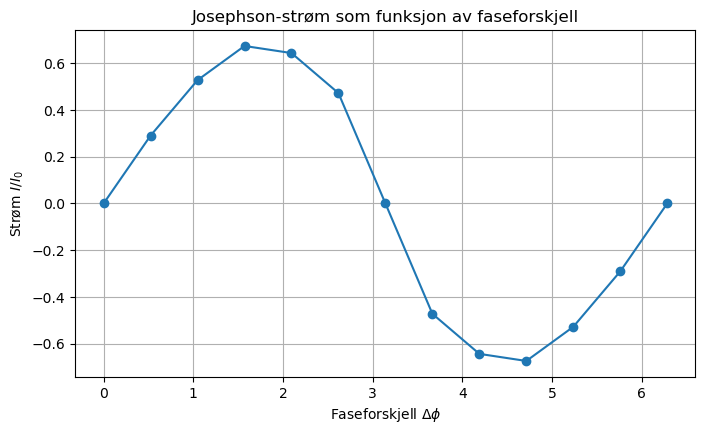

In [33]:
phase_diffs = np.linspace(0, 2 * np.pi, 13)
currents = []

for dphi in phase_diffs:
    energies_desc_dphi, sols_dphi = energy_sweep(
        1.0,
        nE=61,
        m=81,
        phi_L=float(dphi),
        phi_R=0.0,
        tol=2e-3,
    )
    mid_idx = sols_dphi[0].y.shape[1] // 2
    j_vals = np.array([current_integrand(sol.y[:, mid_idx]) for sol in sols_dphi])

    I_val = -simpson(j_vals[::-1], x=energies_desc_dphi[::-1])
    currents.append(I_val)

plt.figure(figsize=(8, 4.5))
plt.plot(phase_diffs, currents, "o-")
plt.xlabel(r"Faseforskjell $\Delta \phi$")
plt.ylabel(r"Strøm $I / I_0$")
plt.title("Josephson-strøm som funksjon av faseforskjell")
plt.show()


**Kommentar:**  
Kurven er periodisk i faseforskjellen, slik en Josephson-relasjon skal være. Den ligner ofte på en sinuskurve, men ikke nødvendigvis en perfekt sinus når junctionen har endelig lengde og vi bruker en mer detaljert mikroskopisk modell. Det viktigste fysiske trekket er den periodiske strøm-fase-relasjonen og at strømmen går til null når faseforskjellen er 0 eller nær $2\pi$.

## Kort oppsummering

- I **Exercise 1** implementerte jeg en adaptiv RK3(2)-løser, sekantmetoden og skytemetoden, og sammenlignet med `solve_bvp`.
- I **Exercise 2** vektoriserte jeg Usadel-likningene, løste dem med `solve_bvp`, beregnet DOS og undersøkte både minigap og Josephson-strøm.
- Resultatene følger den forventede fysikken:
  - normal–normal-grenser gir trivielle løsninger og DOS $=1$
  - superledende grenser gir proximity-effekt og minigap
  - faseforskjell gir ikke-null superstrøm